**핵심 아이디어**
- 행(row)과 열(column)의 교차점마다 값이 있고, 그 값의 크기에 따라 색이 달라짐
- 색이 진하거나 밝을수록 값이 크고, 반대로 연하거나 어두울수록 값이 작음 (사용하는 색상표에 따라 방향은 다를 수 있음)

**주로 쓰이는 경우**

| 용도 | 예시 |
|---|---|
| 상관관계 파악 | 여러 변수 간 관계를 표 하나로 확인 |
| 시간 x 항목 패턴 | 요일별 x 카테고리별 주문 건수 |
| 지리적 분포 | 지역별 x 상품별 평균 가격 |
| 대용량 데이터 탐색 | 수천 개 변수를 한눈에 훑어보기 |

> 히트맵은 "정확한 숫자"보다 "**상대적으로 어디가 크고 작은지**"를 빠르게 파악하는 데 특화된 시각화 방법이다.

In [1]:
import os
from dotenv import load_dotenv
import oracledb
import pandas as pd

load_dotenv()
USER = os.getenv("ORACLE_USER")
PASSWORD = os.getenv("ORACLE_PASSWORD")
DSN = os.getenv("ORACLE_DSN")

with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
    df=pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)
# with문 블록을 벗어나는 순간 자동으로 conn.close()가 호출되어 안정적임

print("연결 및 쿼리 성공! 데이터 shape:", df.shape)
df.head()

연결 및 쿼리 성공! 데이터 shape: (37, 7)


C:\Users\Nopen\AppData\Local\Temp\ipykernel_29400\1881069285.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)


,ORDER_ID,MENU_NAME,CATEGORY,PRICE,RATING,REGION,ORDER_DATE
0,35,짬뽕,중식,9500,4.3,송파구,2026-08-21
1,36,우동,일식,8500,4.1,강남구,2026-08-22
2,37,김밥,분식,5500,4.2,서초구,2026-08-22
3,1,떡볶이,분식,9000,4.5,강남구,2026-08-01
4,2,치킨,치킨,22000,4.8,서초구,2026-08-02


In [2]:
# [셀 1] 한글 폰트 및 마이너스 기호 설정
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)

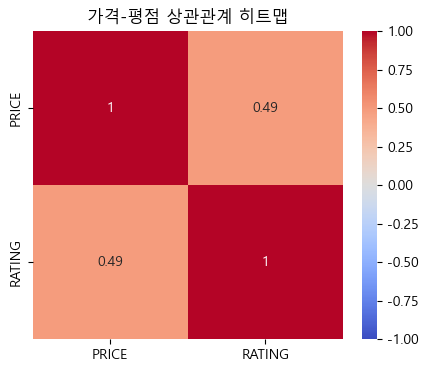

In [3]:
# [셀 2] Seaborn 상관관계 히트맵 시각화
import seaborn as sns

numeric_df = df[["PRICE", "RATING"]]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("가격-평점 상관관계 히트맵")
plt.show()